In [1]:
import os
import copy
import logging
import h5py as h5
import numpy as np
import pandas as pd
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib

import matplotlib.cm as cm



# ------------------------------
# Plot style
# ------------------------------
matplotlib.rcParams.update({
    'font.size': 20,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.major.size': 6,
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.bottom': True,
    'ytick.left': True,
    
    'text.usetex': True,  # Enable LaTeX rendering
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],  # LaTeX default font
})

Zsun = 0.02  
threshold = 1.00 #threshold for MRR, mB > threshold * mA
# ------------------------------
# Load COMPAS data
# ------------------------------

with h5.File("processed_yields_COMPAS.h5", "r") as f:
    z_vals_compas = f["z_values"][()]
    Y_compas      = f["yields"][()]

    # LVK defined M1
    m1_compas     = np.maximum(f["event_properties/mass_1"][()],
                                f["event_properties/mass_2"][()])
    m2_compas     = np.minimum(f["event_properties/mass_1"][()],
                                f["event_properties/mass_2"][()])
    
    MRR_bh_compas = (f["event_properties/mass_2"][()] > threshold *
                     f["event_properties/mass_1"][()])

    Z_compas      = f["event_properties/metallicity"][()]  
    logZrel_compas  = np.log10(Z_compas / Zsun)

    # Just ensure we are grabbing M1 and M2 ZAMS. 
    zams1_compas  = np.maximum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])
    zams2_compas  = np.minimum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])
    
    delay_time_compas = f["event_properties/delay_time_in_years"][()]  

    # MASSquerade

    m1_compas_binary_assumption = f["event_properties/mass_1"][()]
    m2_compas_binary_assumption = f["event_properties/mass_2"][()]

# ------------------------------
# Load SEVN data
# ------------------------------

# with h5.File("processed_yields_SEVN.h5", "r") as f:
with h5.File("../data/yields/sevn_updated.hdf5", "r") as f:
    z_vals_sevn = f["z_values"][()]
    Y_sevn      = f["yields"][()]

    m1_sevn     = np.maximum(f["event_properties/mass_1"][()],
                              f["event_properties/mass_2"][()])
    m2_sevn     = np.minimum(f["event_properties/mass_1"][()],
                              f["event_properties/mass_2"][()])
    MRR_bh_sevn = (f["event_properties/mass_2"][()] > threshold *
                   f["event_properties/mass_1"][()])

    Z_sevn      = f["event_properties/metallicity"][()]
    logZrel_sevn  = np.log10(Z_sevn / Zsun)

    zams1_sevn  = np.maximum(f["event_properties/zams_mass_1"][()],
                              f["event_properties/zams_mass_2"][()])
    zams2_sevn  = np.minimum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])

    delay_time_sevn = f["event_properties/delay_time_in_years"][()]  

    # MASSquerade

    m1_sevn_binary_assumption = f["event_properties/mass_1"][()]
    m2_sevn_binary_assumption = f["event_properties/mass_2"][()]


In [2]:
data = np.load('../data/bgp_rates.npz')
bgp_m1 = data['m1']
bgp_m2 = data['m2']
bgp_R  = data['R']

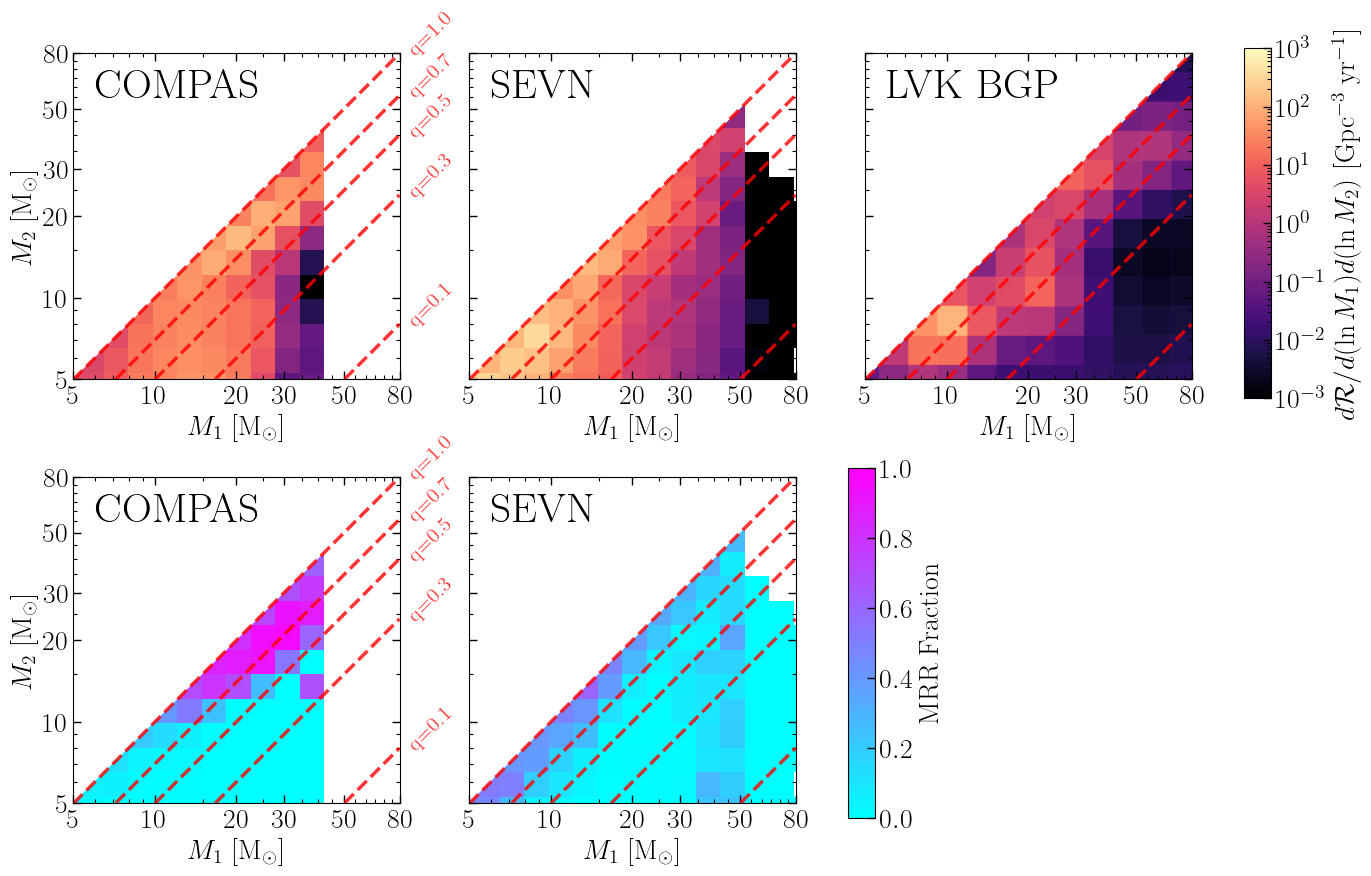

In [3]:
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon
from scipy.stats import binned_statistic_2d
from matplotlib.gridspec import GridSpec



#Bin COMPAS and SEVN for rates AND MRR fraction

log_min, log_max = np.log(1), np.log(180)
n_bins = 25

log_bins = np.linspace(log_min, log_max, n_bins + 1)
bin_centers = 0.5 * (log_bins[:-1] + log_bins[1:])

z_idx = 0

# COMPAS rates
dR_num_compas, _, _, _ = binned_statistic_2d(
    np.log(m1_compas), np.log(m2_compas),
    Y_compas[z_idx, :], statistic='sum', bins=[log_bins, log_bins]
)
bin_area = (log_bins[1] - log_bins[0])**2
dR_log_compas = dR_num_compas / bin_area
dR_log_compas[dR_log_compas == 0] = np.nan
M1_c, M2_c = np.meshgrid(bin_centers, bin_centers, indexing='ij')
dR_log_compas[M2_c > M1_c] = np.nan

# COMPAS MRR
total_rate_compas, _, _, _ = binned_statistic_2d(
    np.log(m1_compas), np.log(m2_compas),
    Y_compas[z_idx, :], statistic='sum', bins=[log_bins, log_bins]
)
mrr_rate_compas, _, _, _ = binned_statistic_2d(
    np.log(m1_compas), np.log(m2_compas),
    Y_compas[z_idx, :] * MRR_bh_compas, statistic='sum', bins=[log_bins, log_bins]
)
mrr_frac_compas = np.divide(mrr_rate_compas, total_rate_compas,
                             where=total_rate_compas > 0,
                             out=np.full_like(mrr_rate_compas, np.nan))
mrr_frac_compas[M2_c > M1_c] = np.nan

# SEVN Rates
dR_num_sevn, _, _, _ = binned_statistic_2d(
    np.log(m1_sevn), np.log(m2_sevn),
    Y_sevn[z_idx, :], statistic='sum', bins=[log_bins, log_bins]
)
dR_log_sevn = dR_num_sevn / bin_area
dR_log_sevn[dR_log_sevn == 0] = np.nan
dR_log_sevn[M2_c > M1_c] = np.nan

# SEVN MRR
total_rate_sevn, _, _, _ = binned_statistic_2d(
    np.log(m1_sevn), np.log(m2_sevn),
    Y_sevn[z_idx, :], statistic='sum', bins=[log_bins, log_bins]
)
mrr_rate_sevn, _, _, _ = binned_statistic_2d(
    np.log(m1_sevn), np.log(m2_sevn),
    Y_sevn[z_idx, :] * MRR_bh_sevn, statistic='sum', bins=[log_bins, log_bins]
)
mrr_frac_sevn = np.divide(mrr_rate_sevn, total_rate_sevn,
                          where=total_rate_sevn > 0,
                          out=np.full_like(mrr_rate_sevn, np.nan))
mrr_frac_sevn[M2_c > M1_c] = np.nan


# add constant-q lines to an axis

def add_q_lines(ax, zoom_min, zoom_max, q_values=[1.0, 0.7, 0.5, 0.3, 0.1],
                color='white', lw=2.5, ls='--', alpha=0.8, fontsize=12, textbool=False):
    m1_log = np.linspace(zoom_min, zoom_max, 500)
    
    for q in q_values:
        # ln(m2) = ln(m1) + ln(q)  →  slope-1 line in log space
        m2_log = m1_log + np.log(q)
        
        # Keep only within plot bounds and below diagonal
        mask = (m2_log >= zoom_min) & (m2_log <= zoom_max) & (m2_log <= m1_log)
        
        if mask.sum() < 2:
            continue
        
        ax.plot(m1_log[mask], m2_log[mask], color="r", lw=lw, ls=ls, alpha=alpha)
        
        # Label at the right end of each line
        right_idx = np.where(mask)[0][-1]
        x_lbl = m1_log[right_idx]+0.1
        y_lbl = m2_log[right_idx]

        if textbool:
            # Nudge label slightly so it doesn't overlap the line
            ax.text(x_lbl, y_lbl, f' q={q}', fontsize=15,
                    color="r", alpha=alpha, va='center', ha='left',
                    rotation=45, rotation_mode='anchor')


# Create 2-row layout: 3 on top, 2 centered on bottom

fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0, height_ratios=[1, 1])

ax_sevn_top   = fig.add_subplot(gs[0, 0])
ax_compas_top = fig.add_subplot(gs[0, 1], sharey=ax_sevn_top)
ax_lvk_top    = fig.add_subplot(gs[0, 2], sharey=ax_sevn_top)
ax_sevn_bot   = fig.add_subplot(gs[1, 0])
ax_compas_bot = fig.add_subplot(gs[1, 1], sharey=ax_sevn_bot)

# Zoom range
zoom_min, zoom_max = np.log(5), np.log(80)

# Tick marks
majors = [5, 10, 20, 30, 50, 80]
major_names = ['5', '10', '20', '30', '50', '80']
xticks = np.log(np.concatenate([np.arange(5, 10), np.arange(10, 80, 5)]))

q_values = [1.0, 0.7, 0.5, 0.3, 0.1]

# ========================================
# TOP ROW: MERGER RATES
# ========================================

# --- TOP LEFT: SEVN ---
im_sevn_top = ax_sevn_top.imshow(
    dR_log_compas.T, cmap='magma', norm=LogNorm(vmin=1e-3, vmax=1e3),
    origin='lower', extent=(0, np.log(180), 0, np.log(180))
)
im_sevn_top.set_clip_path(Polygon(
    np.array([[zoom_min, zoom_min], [zoom_max, zoom_min], [zoom_max, zoom_max]]),
    closed=True, transform=ax_sevn_top.transData
))
ax_sevn_top.set_xlim(zoom_min, zoom_max)
ax_sevn_top.set_ylim(zoom_min, zoom_max)
ax_sevn_top.set_xticks(xticks, minor=True)
ax_sevn_top.set_yticks(xticks, minor=True)
ax_sevn_top.set_xticks(np.log(np.array(majors)), major_names, minor=False)
ax_sevn_top.set_yticks(np.log(np.array(majors)), major_names, minor=False)
ax_sevn_top.set_xlabel(r'$M_1$ [M$_\odot$]')
ax_sevn_top.set_ylabel(r'$M_2$ [M$_\odot$]')
# ax_sevn_top.text(5,75,'SEVN')
ax_sevn_top.text(np.log(6), np.log(55), 'COMPAS',fontsize=30)#, fontsize=12, color='white')
# ax_sevn_top.grid(ls=':', alpha=0.5, lw=1, color='k')
add_q_lines(ax_sevn_top, zoom_min, zoom_max, q_values,textbool=True)

# --- TOP MIDDLE: COMPAS ---
im_compas_top = ax_compas_top.imshow(
    dR_log_sevn.T, cmap='magma', norm=LogNorm(vmin=1e-3, vmax=1e3),
    origin='lower', extent=(0, np.log(180), 0, np.log(180))
)
im_compas_top.set_clip_path(Polygon(
    np.array([[zoom_min, zoom_min], [zoom_max, zoom_min], [zoom_max, zoom_max]]),
    closed=True, transform=ax_compas_top.transData
))
ax_compas_top.set_xlim(zoom_min, zoom_max)
ax_compas_top.set_ylim(zoom_min, zoom_max)
ax_compas_top.set_xticks(xticks, minor=True)
ax_compas_top.set_yticks(xticks, minor=True)
ax_compas_top.set_xticks(np.log(np.array(majors)), major_names, minor=False)
ax_compas_top.set_xlabel(r'$M_1$ [M$_\odot$]')

ax_compas_top.text(np.log(6), np.log(55), 'SEVN',fontsize=30)
# ax_compas_top.grid(ls=':', alpha=0.5, lw=1, color='k')
ax_compas_top.tick_params(labelleft=False)
add_q_lines(ax_compas_top, zoom_min, zoom_max, q_values)

# --- TOP RIGHT: LVK BGP ---
im_lvk_top = ax_lvk_top.imshow(
    bgp_R, cmap='magma', norm=LogNorm(vmin=1e-3, vmax=1e3),
    origin='lower', extent=(0, np.log(180), 0, np.log(180))
)
im_lvk_top.set_clip_path(Polygon(
    np.array([[zoom_min, zoom_min], [zoom_max, zoom_min], [zoom_max, zoom_max]]),
    closed=True, transform=ax_lvk_top.transData
))
ax_lvk_top.set_xlim(zoom_min, zoom_max)
ax_lvk_top.set_ylim(zoom_min, zoom_max)
ax_lvk_top.set_xticks(xticks, minor=True)
ax_lvk_top.set_yticks(xticks, minor=True)
ax_lvk_top.set_xticks(np.log(np.array(majors)), major_names, minor=False)
ax_lvk_top.set_xlabel(r'$M_1$ [M$_\odot$]')
# ax_lvk_top.set_title('LVK BGP')
ax_lvk_top.text(np.log(6), np.log(55), 'LVK BGP',fontsize=30)
# ax_lvk_top.grid(ls=':', alpha=0.5, lw=1, color='k')
ax_lvk_top.tick_params(labelleft=False)
add_q_lines(ax_lvk_top, zoom_min, zoom_max, q_values)

# ========================================
# BOTTOM ROW: MRR FRACTION
# ========================================

# --- BOTTOM LEFT: SEVN MRR ---
im_sevn_bot = ax_sevn_bot.imshow(
    mrr_frac_compas.T, cmap='cool', vmin=0, vmax=1,
    origin='lower', extent=(0, np.log(180), 0, np.log(180))
)
im_sevn_bot.set_clip_path(Polygon(
    np.array([[zoom_min, zoom_min], [zoom_max, zoom_min], [zoom_max, zoom_max]]),
    closed=True, transform=ax_sevn_bot.transData
))
ax_sevn_bot.set_xlim(zoom_min, zoom_max)
ax_sevn_bot.set_ylim(zoom_min, zoom_max)
ax_sevn_bot.set_xticks(xticks, minor=True)
ax_sevn_bot.set_yticks(xticks, minor=True)
ax_sevn_bot.set_xticks(np.log(np.array(majors)), major_names, minor=False)
ax_sevn_bot.set_yticks(np.log(np.array(majors)), major_names, minor=False)
ax_sevn_bot.set_xlabel(r'$M_1$ [M$_\odot$]')
ax_sevn_bot.set_ylabel(r'$M_2$ [M$_\odot$]')
# ax_sevn_bot.set_title('SEVN MRR Fraction')
ax_sevn_bot.text(np.log(6), np.log(55), 'COMPAS',fontsize=30)
# ax_sevn_bot.grid(ls=':', alpha=0.5, lw=1, color='k')
add_q_lines(ax_sevn_bot, zoom_min, zoom_max, q_values, color='k', textbool=True)  # Black lines on coolwarm

# --- BOTTOM MIDDLE: COMPAS MRR ---
im_compas_bot = ax_compas_bot.imshow(
    mrr_frac_sevn.T, cmap='cool', vmin=0, vmax=1,
    origin='lower', extent=(0, np.log(180), 0, np.log(180))
)
im_compas_bot.set_clip_path(Polygon(
    np.array([[zoom_min, zoom_min], [zoom_max, zoom_min], [zoom_max, zoom_max]]),
    closed=True, transform=ax_compas_bot.transData
))
ax_compas_bot.set_xlim(zoom_min, zoom_max)
ax_compas_bot.set_ylim(zoom_min, zoom_max)
ax_compas_bot.set_xticks(xticks, minor=True)
ax_compas_bot.set_yticks(xticks, minor=True)
ax_compas_bot.set_xticks(np.log(np.array(majors)), major_names, minor=False)
ax_compas_bot.set_xlabel(r'$M_1$ [M$_\odot$]')
# ax_compas_bot.set_title('COMPAS MRR Fraction')
ax_compas_bot.text(np.log(6), np.log(55), 'SEVN',fontsize=30)
# ax_compas_bot.grid(ls=':', alpha=0.5, lw=1, color='k')
ax_compas_bot.tick_params(labelleft=False)
add_q_lines(ax_compas_bot, zoom_min, zoom_max, q_values, color='k')  # Black lines on coolwarm


# Manual layout adjustment

fig.subplots_adjust(left=0.2, right=0.86, top=0.95, bottom=0.2, wspace=0)

cbar_ax_top = fig.add_axes([0.87, 0.605, 0.015, 0.35]) # last is width, height
cbar_top = fig.colorbar(im_lvk_top, cax=cbar_ax_top)
cbar_top.set_label(r'$d\mathcal{R}/d(\ln M_1)d(\ln M_2)$ [Gpc$^{-3}$ yr$^{-1}$]', fontsize=20)

cbar_ax_bot = fig.add_axes([0.65, 0.185, 0.015, 0.35]) # left, bottom, 
cbar_bot = fig.colorbar(im_compas_bot, cax=cbar_ax_bot)
cbar_bot.set_label('MRR Fraction', fontsize=20)

plt.savefig("../plots/final-sevn-compas-lvk-mrr-comparison.pdf", bbox_inches=None)
plt.show()

#I swapped compas and sevn, but some of the code is now mislabeled, but it works so I haven't changed it... 

# NOTE: I swapped compas and sevn, but some of the code is now mislabeled, but it works so I haven't changed it... 